# Linking structure to function — closing figures

Two publication figures for the TFM (A. de Haro García, adv. M. Á. Serrano, UB):

* **Figure 1 — Memory capacity across the lifespan and its structural predictors.**
  ESN/MC paradigm (built from one real connectome) · MC, disparity, clustering and
  communicability trajectories · the MC–disparity developmental linearization ·
  a signed-*r* horse-race (development vs aging) and the structural-explanation bars.
* **Figure 2 — The communicability decomposition, the regime change, and the multivariate picture.**
  Taylor validation of the self-communicability expansion · the R² decomposition of MC
  (Table III) for development vs aging · a PCA of the coupled structural family.

Memory capacity is computed by five small C++/Eigen programs (`cpp/`, parallelised with
OpenMP). All structural quantities are computed here in Python from the connectome
matrices. Everything is cached to `procdata/`; set `FORCE_RECOMPUTE`/`FORCE_RECOMPILE`
to redo work. The notebook is autonomous: run top to bottom.


## 0 · Parameters

In [19]:
# ---- paths -----------------------------------------------------------------
from pathlib import Path
import os

DATA_PKL   = Path("../procdata/data_with_metrics.pkl")   # one row per connectome
WORK_DIR   = Path("procdata"); WORK_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR    = Path("figures");  FIG_DIR.mkdir(exist_ok=True, parents=True)
CPP_DATA   = Path("data");  CPP_DATA.mkdir(exist_ok=True, parents=True)

# ---- recompute switches ----------------------------------------------------
FORCE_RECOMPILE  = False    # rebuild the C++ binaries
FORCE_RECOMPUTE  = False    # rerun every C++ experiment (ignore caches)
SEED             = 42

# ---- toolchain knobs (one-time, Windows/MSYS2) -----------------------------
# Override if autodetection fails:
#   os.environ["GPP"]            = r"C:\msys64\ucrt64\bin\g++.exe"
#   os.environ["EIGEN_INCLUDE"]  = r"C:\path\to\eigen-master"
N_THREADS        = 0        # 0 = let OpenMP use all cores

# ---- ESN hyperparameters (kept reasonable; not tuned, per the manuscript) --
RES = dict(reservoir_size=90, spectral_radius=0.99, ridge=1e-6,
           train_ratio=0.7, washout=1000)

# main MC experiment (all subjects -> the workhorse)
MAIN   = dict(steps=10000, tau=20, win_reps=1)
# surrogates / bio / ipc run on a balanced subject subset
SUBSET_N      = 100
SURR   = dict(steps=10000, tau=20, n_real=5)
BIO    = dict(steps=1000, tau=20, win_reps=1, thal_nodes="76,77", n_rand_pairs=50)
IPC    = dict(steps=1000, ipc_tau=6, ipc_cross=True, tau=20)
TRACE  = dict(steps=10000, tau=50, trace_window=200, trace_nodes=6, trace_taus="1,8")

# ---- analysis constants ----------------------------------------------------
AGE_SPLIT = 32                       # development (<32) vs aging (>=32)
RHO       = 0.99                     # spectral-radius normalisation for communicability
N_AGE_BINS = 100                      # geometric age bins for trajectories
PLOT_SUBSET = 1500                   # max points drawn in scatter layers (age-balanced)

DS_NAMES = {1:"dHCP",2:"BCP",3:"CALM",4:"RED",5:"ACE",
            6:"HCPd",7:"HCPya",8:"camCAN",9:"HCPa"}
CAMCAN_DS = 8                        # for the Mijalkov thresholding contrast

FIG_PARTS  = FIG_DIR / "fig1_parts"; FIG_PARTS.mkdir(exist_ok=True, parents=True)
AAL_NII    = Path("../preprocdata/aal-SPM12/aal/atlas/AAL.nii")   # nilearn node glyph


def sig_stars(p):
    import numpy as np
    if not np.isfinite(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


## 1 · Imports and plotting style
Matches `firstpart.ipynb`. `networkx`/`umap` are optional — panels that need them degrade gracefully.

In [20]:
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import seaborn as sns
from scipy.linalg import expm, eigvals
from scipy.stats import pearsonr, f as f_dist
import warnings, subprocess, shutil, platform, pickle
warnings.filterwarnings("ignore")

try:
    import networkx as nx; HAS_NX = True
except Exception:
    HAS_NX = False
try:
    import umap; HAS_UMAP = True
except Exception:
    HAS_UMAP = False

sns.set_theme(style="ticks", context="paper")
mpl.rcParams.update({
    "font.size":7, "axes.titlesize":7, "axes.labelsize":7,
    "xtick.labelsize":8, "ytick.labelsize":8, "legend.fontsize":7,
    "lines.linewidth":0.9, "lines.markersize":2.5,
    "figure.dpi":150, "savefig.dpi":300,
    "pdf.fonttype":42, "ps.fonttype":42, "svg.fonttype":"none",
    "axes.spines.top":False, "axes.spines.right":False,
})
FIGSIZE = (11, 7.5)

# colour-blind-safe palette used throughout
COL = dict(mc="#2A9D8F", disp="#C0392B", clust="#F39C12", comm="#2980B9",
           dev="#E1A100", aging="#6A3D9A", null="#9AA0A6", accent="#C0392B")
COHORT_COL = {"development": COL["dev"], "aging": COL["aging"]}
DS_PALETTE = dict(zip(range(1,10), sns.color_palette("tab10", 9)))

def save_fig(fig, name, d=None):
    d = d or FIG_DIR
    for ext in ("pdf","png"):
        fig.savefig(d / f"{name}.{ext}", dpi=300, bbox_inches="tight",
                    transparent=(d is not FIG_DIR))
    print("saved", d / f"{name}.[pdf|png]")
print("networkx:", HAS_NX, "| umap:", HAS_UMAP, "| platform:", platform.system())


networkx: True | umap: True | platform: Windows


## 2 · Structural helpers

The DataFrame already carries per-subject disparity (`Ratio` = Υ/Υ_null, `kY_obs`),
weighted clustering (`C_w`) and the off-diagonal communicability (`comm_mean`). Here we
add the quantities the **decomposition** needs and that are not pre-computed:

* the **diagonal self-communicability** $C_{ii}=(e^{W})_{ii}$ and its order-2 / order-3
  Taylor terms $\tfrac12(W^2)_{ii}$ (∝ disparity) and $(W^3)_{ii}/6$ (∝ clustering),
* per-node off-diagonal communicability $G_i$,
* Zhang–Horvath weighted clustering (its numerator *is* $(W^3)_{ii}$, so it is the
  clustering coefficient that matches the order-3 term exactly — Onnela's cube-root
  version is provided too for the text),

plus statistics utilities (OLS R², partial correlation, geometric-bin trajectories with
bootstrap CIs, proportional thresholding, age-balanced sampling).

In [21]:
# ---------- node-level weight statistics ----------
def node_metrics(A):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    s = A.sum(1); k = (A > 0).sum(1).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        P = np.where(s[:,None] > 0, A / s[:,None], 0.0)
    Y = (P**2).sum(1)
    return dict(strength=s, degree=k, disparity_Y=Y, kY=k*Y)

def spectral_normalize(A, rho=RHO):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    ev = np.abs(eigvals(A)); sr = ev.max() if ev.size else 0.0
    return A * (rho / sr) if sr > 0 else A

# ---------- communicability (diagonal = self/subgraph; off-diagonal = global) ----------
def communicability_parts(A, rho=RHO):
    W = spectral_normalize(A, rho); N = W.shape[0]
    C = expm(W); dC = np.diag(C).copy()
    off_mean = (C.sum() - dC.sum()) / (N*(N-1))
    off_node = (C.sum(1) - dC) / (N-1)
    return dict(W=W, self_comm=dC, G_off_mean=off_mean, G_off_node=off_node)

def taylor_terms(W):
    W2 = W @ W; W3 = W2 @ W
    t2 = 0.5*np.diag(W2)          # order-2  (∝ disparity:  (W^2)_ii = s^2 Y)
    t3 = np.diag(W3)/6.0          # order-3  (∝ clustering)
    return dict(t2=t2, t3=t3, approx2=1.0+t2)

# ---------- weighted clustering ----------
def clustering_zhang_horvath(A):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    m = A.max(); W = A/m if m > 0 else A
    num = np.diag(W @ W @ W)
    den = W.sum(1)**2 - (W**2).sum(1)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den > 0, num/den, 0.0)

def clustering_onnela(A):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    m = A.max(); W = A/m if m > 0 else A
    Wc = np.cbrt(W); t = np.diag(Wc @ Wc @ Wc)
    k = (A > 0).sum(1).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(k > 1, t/(k*(k-1)), 0.0)

# ---------- statistics ----------
def fit_linear(X, y):
    X = np.asarray(X, float); y = np.asarray(y, float)
    if X.ndim == 1: X = X[:,None]
    M = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    X, y = X[M], y[M]
    A = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    yhat = A @ beta
    ss_res = float(((y-yhat)**2).sum()); ss_tot = float(((y-y.mean())**2).sum())
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
    n, p = len(y), X.shape[1]
    if ss_res > 0 and n-p-1 > 0 and 0 < r2 < 1:
        F = (r2/p)/((1-r2)/(n-p-1)); pval = float(f_dist.sf(F, p, n-p-1))
    else:
        pval = np.nan
    return r2, pval

def pearson_p(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    M = np.isfinite(x) & np.isfinite(y)
    if M.sum() < 3: return np.nan, np.nan
    r, p = pearsonr(x[M], y[M]); return float(r), float(p)

def partial_r(x, y, covars):
    x = np.asarray(x, float); y = np.asarray(y, float)
    Z = np.asarray(covars, float)
    if Z.ndim == 1: Z = Z[:,None]
    M = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(Z), axis=1)
    x, y, Z = x[M], y[M], Z[M]
    if len(x) < 5: return np.nan, np.nan
    A = np.column_stack([np.ones(len(x)), Z])
    rx = x - A @ np.linalg.lstsq(A, x, rcond=None)[0]
    ry = y - A @ np.linalg.lstsq(A, y, rcond=None)[0]
    return pearson_p(rx, ry)

def fdr_bh(pvals):
    p = np.asarray(pvals, float); n = p.size
    if n == 0: return p
    order = np.argsort(p); ranked = np.empty(n); ranked[order] = np.arange(1, n+1)
    q = p * n / ranked
    qs = q[order]; qs = np.minimum.accumulate(qs[::-1])[::-1]
    out = np.empty(n); out[order] = qs
    return np.clip(out, 0, 1)

def binned_xy(x, y, n_bins=12, n_boot=400, seed=SEED, geom=False):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if x.size < 6: return tuple(np.array([]) for _ in range(4))
    edges = (np.geomspace(max(x.min(),1e-6), x.max(), n_bins+1) if geom
             else np.linspace(x.min(), x.max(), n_bins+1))
    idx = np.clip(np.digitize(x, edges)-1, 0, n_bins-1)
    rng = np.random.default_rng(seed); cen, mean, lo, hi = [], [], [], []
    for b in range(n_bins):
        v = y[idx == b]
        if v.size < 3: continue
        cen.append(0.5*(edges[b]+edges[b+1])); mean.append(v.mean())
        bs = np.array([rng.choice(v, v.size, replace=True).mean() for _ in range(n_boot)])
        lo.append(np.percentile(bs, 2.5)); hi.append(np.percentile(bs, 97.5))
    return tuple(np.array(z) for z in (cen, mean, lo, hi))

# ---------- trajectories ----------
def geom_age_bins(age, n_bins=N_AGE_BINS, floor=0.25):
    a = np.clip(np.asarray(age, float), floor, None)
    edges = np.geomspace(a.min(), a.max(), n_bins+1)
    idx = np.clip(np.digitize(a, edges)-1, 0, n_bins-1)
    return edges, idx

def binned_trajectory(age, val, n_bins=N_AGE_BINS, n_boot=400, seed=SEED):
    age = np.asarray(age, float); val = np.asarray(val, float)
    M = np.isfinite(age) & np.isfinite(val); age, val = age[M], val[M]
    edges, idx = geom_age_bins(age, n_bins)
    rng = np.random.default_rng(seed)
    cen, mean, lo, hi = [], [], [], []
    for b in range(n_bins):
        v = val[idx == b]
        if v.size < 3: continue
        cen.append(float(np.sqrt(edges[b]*edges[b+1]))); mean.append(float(v.mean()))
        bs = np.array([rng.choice(v, v.size, replace=True).mean() for _ in range(n_boot)])
        lo.append(float(np.percentile(bs, 2.5))); hi.append(float(np.percentile(bs, 97.5)))
    return tuple(np.array(z) for z in (cen, mean, lo, hi))

# ---------- misc ----------
def proportional_threshold(A, density):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0); N = A.shape[0]
    iu = np.triu_indices(N, 1); w = A[iu]
    keep = int(round(density * w.size))
    if keep < 1 or (w > 0).sum() == 0: return np.zeros_like(A)
    thr = np.sort(w)[::-1][min(keep, w.size)-1]
    M = np.where(A >= thr, A, 0.0); np.fill_diagonal(M, 0.0); return M

def inverse_freq_sample(df, n, seed=SEED, age_col="age"):
    # age-balanced subsample: P(row) proportional to 1 / (#rows at that rounded age).
    # Done with numpy.choice (pandas' own weighted no-replacement sampler is overly strict).
    n = min(n, len(df))
    if n >= len(df):
        return df.copy()
    rng = np.random.default_rng(seed)
    vc = df[age_col].round().value_counts()
    w = (1.0 / df[age_col].round().map(vc)).fillna(0.0).to_numpy()
    if w.sum() <= 0:
        idx = rng.choice(len(df), size=n, replace=False)
    else:
        idx = rng.choice(len(df), size=n, replace=False, p=w / w.sum())
    return df.iloc[idx]


## 3 · Load data, derive features, choose the analysis sample

We load `data_with_metrics.pkl`, build a stable `sid = arange(len(df))` (used as the
C++ merge key, since there is no subject id), and compute the per-subject decomposition
features (mean self-communicability, mean order-2/order-3 Taylor terms, mean
Zhang–Horvath clustering, mean off-diagonal $G_i$) directly from the `connectome`
matrices. The columns already present (`Ratio`, `kY_obs`, `C_w`, `comm_mean`,
`strength`, `degree`, `density`) are reused as-is.

In [22]:
assert DATA_PKL.exists(), f"missing {DATA_PKL} — put data_with_metrics.pkl under procdata/"
df = pd.read_pickle(DATA_PKL).reset_index(drop=True)
df["sid"] = np.arange(len(df))
print(f"{len(df)} connectomes | columns: {list(df.columns)}")
print("datasets:", sorted(df['dataset'].unique()), "| age range:",
      round(df['age'].min(),2), "-", round(df['age'].max(),2))

def _mat(x):
    A = np.asarray(x, float)
    if A.ndim == 1:                      # flattened -> square
        n = int(round(np.sqrt(A.size))); A = A.reshape(n, n)
    np.fill_diagonal(A, 0.0); return A

N_NODES = _mat(df.iloc[0]["connectome"]).shape[0]
print("N nodes per connectome:", N_NODES)
RES["reservoir_size"] = N_NODES


3901 connectomes | columns: ['age', 'dataset', 'sex', 'connectome', 'decade', 'density', 'strength', 'degree', 'Y_obs', 'kY_obs', 'Y_null', 'Ratio', 'C_unw', 'C_w', 'comm_mean', 'sc_mean', 'sid']
datasets: [1, 2, 3, 4, 5, 6, 7, 8, 9] | age range: 0 - 90
N nodes per connectome: 90


In [23]:
# Check connectomes for (1) self-loops and (2) non-symmetry
n_total = len(df)
self_loop_count = 0
nonsym_count = 0

for A_raw in df["connectome"]:
    A = np.asarray(A_raw, dtype=float)
    if A.ndim == 1:  # flattened connectome
        n = int(round(np.sqrt(A.size)))
        A = A.reshape(n, n)

    if np.any(np.diag(A) != 0):
        self_loop_count += 1

    if not np.allclose(A, A.T, atol=1e-10, rtol=0):
        nonsym_count += 1

print(f"Total connectomes: {n_total}")
print(f"Self-loops: {self_loop_count}/{n_total} ({self_loop_count/n_total:.2%})")
print(f"Non-symmetric: {nonsym_count}/{n_total} ({nonsym_count/n_total:.2%})")


Total connectomes: 3901
Self-loops: 0/3901 (0.00%)
Non-symmetric: 0/3901 (0.00%)


In [24]:
# ---- per-subject decomposition features (cached: depends only on connectomes) ----
FEAT_PKL = WORK_DIR / "struct_features_v2.pkl"          # bumped: adds s2n_mean, Y_mean
if FEAT_PKL.exists():
    feats = pd.read_pickle(FEAT_PKL)
    print("loaded cached structural features:", feats.shape)
else:
    rows = []
    for sid, A in zip(df["sid"], df["connectome"]):
        A = _mat(A)
        cp = communicability_parts(A, RHO); tt = taylor_terms(cp["W"])
        zh = clustering_zhang_horvath(A)

        Wn  = np.asarray(cp["W"])                        # spectral-normalised W̃
        s_n = Wn.sum(1).ravel()                          # normalised strength per node
        with np.errstate(divide="ignore", invalid="ignore"):
            P = Wn / s_n[:, None]
        Y_n = np.nansum(P**2, axis=1)                    # local disparity (scale-invariant)

        rows.append(dict(sid=int(sid),
            self_comm_mean = float(cp["self_comm"].mean()),
            G_off_mean     = float(cp["G_off_mean"]),
            T2_mean        = float(tt["t2"].mean()),
            T3_mean        = float(tt["t3"].mean()),
            Cw_zh_mean     = float(zh.mean()),
            s2n_mean       = float((s_n**2).mean()),      # ⟨s̃²⟩  (strength scale)
            Y_mean         = float(Y_n.mean())))          # ⟨Y⟩    (heterogeneity shape)
        if (sid+1) % 500 == 0: print(f"  features {sid+1}/{len(df)}")
    feats = pd.DataFrame(rows); feats.to_pickle(FEAT_PKL)
    print("computed structural features:", feats.shape)

df = df.merge(feats, on="sid", how="left")

df["cohort"] = np.where(df["age"] <= AGE_SPLIT, "development", "aging")

loaded cached structural features: (3901, 8)


In [25]:
# ---- analysis sample: all subjects get MC; a balanced subset feeds the heavy runs ----
df_sub = inverse_freq_sample(df, SUBSET_N, seed=SEED).reset_index(drop=True)
print(f"balanced subset for surrogate/bio/ipc: {len(df_sub)} subjects "
      f"(ages {df_sub['age'].min():.1f}-{df_sub['age'].max():.1f})")

# one connectome near the median age for the paradigm trace
trace_row = df.iloc[(df["age"] - df["age"].median()).abs().argmin()]
print("paradigm trace subject sid:", int(trace_row["sid"]), "| age:", round(float(trace_row["age"]),1))


balanced subset for surrogate/bio/ipc: 100 subjects (ages 0.0-88.0)
paradigm trace subject sid: 1496 | age: 27.0


## 4 · Echo-State-Network engine (C++ / Eigen / OpenMP)

The five programs in `cpp/` are compiled once (cached) and driven through `config.txt`
files. The toolchain is auto-detected — MSYS2 **ucrt64** first, then `PATH`, then common
roots; override with `os.environ["GPP"]` / `os.environ["EIGEN_INCLUDE"]`. Connectomes are
exported as `[subject_id, flattened NxN]` CSVs; every result is cached to `procdata/`.

In [26]:
def _gpp_and_eigen():
    exe = ".exe" if platform.system() == "Windows" else ""
    gpp = os.environ.get("GPP") or r"C:\msys64\ucrt64\bin\g++.exe"
    if not Path(gpp).exists():
        gpp = shutil.which("g++") or "g++"
    # Eigen 3.4 ESTABLE (el que ya te funciona) — NO uses eigen-master, rompe el compilador.
    eig = os.environ.get("EIGEN_INCLUDE", "")
    if not eig or not (Path(eig)/"Eigen"/"Dense").exists():
        for p in [r"C:\rtools45\x86_64-w64-mingw32.static.posix\include\eigen3",
                  str("eigen-master"), str("eigen-master")]:
            if (Path(p)/"Eigen"/"Dense").exists(): eig = p; break
    return gpp, eig, exe

PROGRAMS = ["esn_mc","esn_surrogates","esn_bio","esn_ipc","esn_trace"]

def compile_programs():
    gpp, eig, exe = _gpp_and_eigen()
    if not eig:
        raise RuntimeError("Eigen not found. Put 'eigen-master' next to cpp/ or set "
                           "os.environ['EIGEN_INCLUDE'].")
    print("g++   :", gpp, "\neigen :", eig)
    flags = ["-std=c++17","-O2","-fopenmp", f"-I{eig}", "-w"]
    for prog in PROGRAMS:
        out = Path(f"{prog}{exe}")
        if out.exists() and not FORCE_RECOMPILE:
            print("  cached", out.name); continue
        cmd = [gpp, *flags, str(f"{prog}.cpp"), "-o", str(out)]
        env = dict(os.environ); env["PATH"] = r"C:\msys64\ucrt64\bin" + os.pathsep + env.get("PATH","")
        r = subprocess.run(cmd, capture_output=True, text=True, env=env)
        if r.returncode != 0:
            print(r.stderr[-2000:]); raise RuntimeError(f"compile failed: {prog}")
        print("  built ", out.name)
    return exe

def write_config(path, **kw):
    with open(path, "w") as f:
        for k, v in kw.items(): f.write(f"{k}={v}\n")

def export_connectomes(frame, path):
    with open(path, "w") as f:
        f.write("subject_id," + ",".join(f"w{k}" for k in range(N_NODES*N_NODES)) + "\n")
        for sid, A in zip(frame["sid"], frame["connectome"]):
            flat = _mat(A).flatten()
            f.write(f"{int(sid)}," + ",".join(f"{v:.6g}" for v in flat) + "\n")

def run_program(prog, cfg, exe):
    env = dict(os.environ); env["PATH"] = r"C:\msys64\ucrt64\bin" + os.pathsep + env.get("PATH","")
    proc = subprocess.Popen([str(Path(f"{prog}{exe}").resolve()), str(cfg)],
                            env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout: print(line, end="")
    proc.wait()
    if proc.returncode != 0: raise RuntimeError(f"{prog} failed (code {proc.returncode})")

EXE = compile_programs()


g++   : C:\msys64\ucrt64\bin\g++.exe 
eigen : C:\rtools45\x86_64-w64-mingw32.static.posix\include\eigen3
  cached esn_mc.exe
  cached esn_surrogates.exe
  cached esn_bio.exe
  cached esn_ipc.exe
  cached esn_trace.exe


### 4a · Main memory capacity — all subjects (the workhorse, feeds both figures)

In [27]:
mc_cache = WORK_DIR / "mc_main.pkl"
if mc_cache.exists() and not FORCE_RECOMPUTE:
    mc_main = pd.read_pickle(mc_cache); print("loaded cached MC:", mc_main.shape)
else:
    export_connectomes(df, CPP_DATA/"connectomes_all.csv")
    write_config("cfg_mc.txt", **RES, **MAIN, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_all.csv", out_csv="mc_main.csv")
    run_program("esn_mc", "cfg_mc.txt", EXE)
    mc_main = pd.read_csv("mc_main.csv").rename(columns={"MC_Glob":"MC"})
    mc_main.to_pickle(mc_cache)
df = df.merge(mc_main[["subject_id","MC"]].rename(columns={"subject_id":"sid"}),
              on="sid", how="left")
print("MC range:", round(df['MC'].min(),2), "-", round(df['MC'].max(),2),
      "| median:", round(df['MC'].median(),2))


loaded cached MC: (3901, 2)
MC range: 5.58 - 8.53 | median: 7.1


### 4b · Weight surrogates — MC of the real network vs three nulls (boxplots)

In [28]:
surr_cache = WORK_DIR / "mc_surrogates.pkl"
if surr_cache.exists() and not FORCE_RECOMPUTE:
    surr = pd.read_pickle(surr_cache); print("loaded cached surrogates:", surr.shape)
else:
    export_connectomes(df_sub, CPP_DATA/"connectomes_sub.csv")
    write_config("cfg_surr.txt", **RES, **SURR, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_sub.csv", out_csv="surr.csv")
    run_program("esn_surrogates", "cfg_surr.txt", EXE)
    surr = pd.read_csv("surr.csv"); surr.to_pickle(surr_cache)
print(surr.groupby("model")["MC"].mean().round(3))


loaded cached surrogates: (2500, 4)
model
BrokenStick    6.858
Real           7.097
Reshuffle      7.419
SignFlip       7.259
Uniform        6.358
Name: MC, dtype: float64


### 4c · Biological input — MC vs thalamic input vs random-pair null

In [29]:
bio_cache = WORK_DIR / "mc_bio.pkl"
if bio_cache.exists() and not FORCE_RECOMPUTE:
    bio = pd.read_pickle(bio_cache); print("loaded cached bio:", bio.shape)
else:
    export_connectomes(df_sub, CPP_DATA/"connectomes_sub.csv")
    write_config("cfg_bio.txt", **RES, **BIO, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_sub.csv", out_csv="bio.csv")
    run_program("esn_bio", "cfg_bio.txt", EXE)
    bio = pd.read_csv("bio.csv"); bio.to_pickle(bio_cache)
print(bio[["MC","MC_Bio","MC_BioNull"]].mean().round(3))


loaded cached bio: (100, 4)
MC            7.032
MC_Bio        7.717
MC_BioNull    7.835
dtype: float64


### 4d · Information processing capacity — Legendre orders

In [30]:
ipc_cache = WORK_DIR / "mc_ipc.pkl"
if ipc_cache.exists() and not FORCE_RECOMPUTE:
    ipc = pd.read_pickle(ipc_cache); print("loaded cached ipc:", ipc.shape)
else:
    export_connectomes(df_sub, CPP_DATA/"connectomes_sub.csv")
    write_config("cfg_ipc.txt", **RES, **IPC, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_sub.csv", out_csv="ipc.csv")
    run_program("esn_ipc", "cfg_ipc.txt", EXE)
    ipc = pd.read_csv("ipc.csv"); ipc.to_pickle(ipc_cache)
print(ipc[[c for c in ipc.columns if c != "subject_id"]].mean().round(4))


loaded cached ipc: (100, 4)
Lin        5.5534
Quad       0.0078
Cross11    0.0193
dtype: float64


### 4e · Single-subject trace — ingredients of the MC paradigm (Figure 1 top)

In [31]:
trace_cache = WORK_DIR / "trace.pkl"
if trace_cache.exists() and not FORCE_RECOMPUTE:
    trace = pickle.load(open(trace_cache,"rb")); print("loaded cached trace")
else:
    one = df[df["sid"] == int(trace_row["sid"])]
    export_connectomes(one, CPP_DATA/"connectome_one.csv")
    write_config("cfg_trace.txt", **RES, **TRACE, seed=SEED,
                 in_csv="data/connectome_one.csv", trace_dir=".")
    run_program("esn_trace", "cfg_trace.txt", EXE)
    trace = {k: pd.read_csv(f"trace_{k}.csv")
             for k in ["input","states","readout","mccurve"]}
    pickle.dump(trace, open(trace_cache,"wb"))
print("trace MC(tau) total:", round(trace["mccurve"]["r2"].sum(),3))


loaded cached trace
trace MC(tau) total: 6.366


## 5 · Figure 1 — MC paradigm

The paradigm row (brain reservoir, input, states, readout, memory curve) is exported as
**separate pieces** to `figures/fig1_parts/` for assembly in Inkscape; Figure 1 itself
keeps a placeholder for that band. The analytical panels show the lifespan U of memory
capacity with disparity overlaid, MC vs disparity split by regime, and the development /
aging horse-race with the structural-explanation bars.

In [32]:
def _save_part(fig, name):
    for ext in ("pdf","png"):
        fig.savefig(FIG_PARTS/f"{name}.{ext}", dpi=600, bbox_inches="tight", transparent=True)
    plt.close(fig); print("  part:", name)

ti = trace["input"]; n = min(140, len(ti))
f = plt.figure(figsize=(2.0,0.8)); ax = f.add_axes([0,0,1,1])
ax.plot(np.arange(n), ti["u"].values[:n], color="#5f6368", lw=3.0, solid_capstyle="round"); ax.axis("off")
_save_part(f, "input")

st = trace["states"]; scols = [c for c in st.columns if c.startswith("x")][:4]; m = min(140,len(st))
f = plt.figure(figsize=(2.0,1.2)); ax = f.add_axes([0,0,1,1])
for i,c in enumerate(scols):
    ax.plot(np.arange(m), st[c].values[:m] + i*2.4, color=COL["comm"], lw=2.2, solid_capstyle="round")
ax.axis("off"); _save_part(f, "reservoir_states")

rd = trace["readout"]; mm = min(140, len(rd))
f = plt.figure(figsize=(2.0,0.8)); ax = f.add_axes([0,0,1,1])
ax.plot(np.arange(mm), rd["yhat_tauA"].values[:mm], color=COL["clust"], lw=3.0, solid_capstyle="round"); ax.axis("off")
_save_part(f, "readout")

mc = trace["mccurve"]
f = plt.figure(figsize=(1.9,1.35)); ax = f.add_axes([0.20,0.22,0.76,0.72])
ax.plot(mc["tau"], mc["r2"], "-o", color=COL["mc"], lw=2.6, ms=3, solid_capstyle="round")
ax.fill_between(mc["tau"], 0, mc["r2"], color=COL["mc"], alpha=0.15)
sns.despine(ax=ax); ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$r^2$"); ax.tick_params(labelsize=6)
_save_part(f, "memory_curve")
print("paradigm parts ->", FIG_PARTS.resolve())

  part: input
  part: reservoir_states
  part: readout
  part: memory_curve
paradigm parts -> C:\Users\Ale\Desktop\UB\NetLearn\ESNcpp\figures\fig1_parts


In [33]:
mc.columns

Index(['tau', 'r2'], dtype='object')

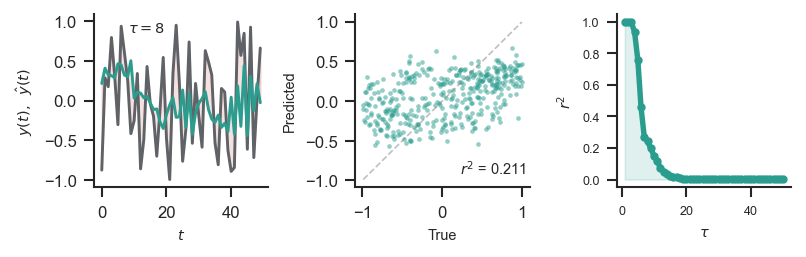

In [34]:
rd = trace["readout"]

ytrue = rd["y_tauB"].to_numpy()
yhat  = rd["yhat_tauB"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(6,1.5), gridspec_kw={"wspace":0.5})

ax = axes[0]
nn = min(50, len(ytrue))
ax.plot(ytrue[:nn], color="#5f6368", lw=1.4, label="True")
ax.plot(yhat[:nn],  color=COL["mc"],  lw=1.4, label="Predicted")
ax.fill_between(range(nn), ytrue[:nn], yhat[:nn], color=COL["disp"], alpha=0.15)
ax.set_xlabel("$t$"); ax.set_ylabel("$y(t), \;\; \hat{y}(t)$")
ax.text(0.3, 0.96, "$\\tau = 8$", transform=ax.transAxes,
        ha="center", va="top", fontsize=7)
#ax.legend(loc="upper right", frameon=False, fontsize=7)
sns.despine(ax=ax)

ax = axes[1]
ax.scatter(ytrue, yhat, s=5, alpha=0.5, color=COL["mc"], linewidths=0)
lims = [min(ytrue.min(), yhat.min()), max(ytrue.max(), yhat.max())]
ax.plot(lims, lims, lw=0.8, ls="--", color="gray", alpha=0.5)
r2 = pearsonr(ytrue, yhat)[0]**2
ax.text(0.98, 0.06, f"$r^2$ = {r2:.3f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=7)
ax.set_xlabel("True"); ax.set_ylabel("Predicted")
sns.despine(ax=ax)

ax = axes[2]
mc = trace["mccurve"]
ax.plot(mc["tau"], mc["r2"], "-o", color=COL["mc"], lw=2.6, ms=3, solid_capstyle="round")
ax.fill_between(mc["tau"], 0, mc["r2"], color=COL["mc"], alpha=0.15)
sns.despine(ax=ax); ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$r^2$"); ax.tick_params(labelsize=6)


plt.savefig(FIG_PARTS/"trace_fit.pdf", dpi=600, bbox_inches="tight", transparent=True)
plt.tight_layout()

plt.show()

In [35]:
try:
    from nilearn import plotting
    from nilearn.plotting import find_parcellation_cut_coords
    if AAL_NII.exists():
        coords = find_parcellation_cut_coords(labels_img=str(AAL_NII))[:N_NODES]
        
        node_val = np.ones(len(coords))
        disp = plotting.plot_markers(node_values=node_val, node_coords=coords,
                                     display_mode="x", node_size=28,node_cmap="Purples", 
                                     colorbar=False, alpha=0.9)
        for ext in ("pdf","png"): disp.savefig(FIG_PARTS/f"brain_nodes.{ext}", dpi=600)
        disp.close(); print("  part: brain_nodes (nilearn,", len(coords), "nodes)")
    else:
        print("AAL.nii not found at", AAL_NII)
except Exception as e:
    print("nilearn brain glyph skipped:", str(e)[:130])

  part: brain_nodes (nilearn, 90 nodes)


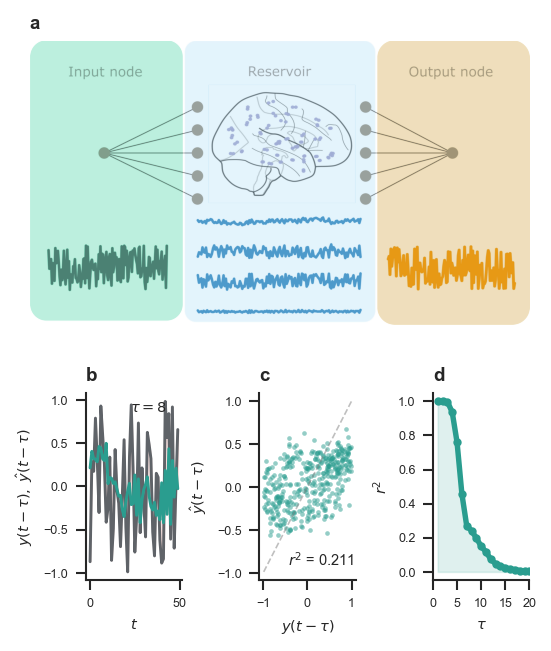

In [36]:
import matplotlib.image as mpimg
import numpy as np

def load_png_cropped(path, tol=0.02):
    """Trim transparent OR white border, whichever the export used."""
    img = mpimg.imread(path)
    rgb = img[..., :3]
    opaque  = img[..., 3] > tol if img.shape[-1] == 4 else np.ones(img.shape[:2], bool)
    colored = rgb.max(-1) < (1 - tol)          # not near-white
    ys, xs  = np.where(opaque & colored)
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1] if len(ys) else img

rd = trace["readout"]
ytrue = rd["y_tauB"].to_numpy(); yhat = rd["yhat_tauB"].to_numpy()

para = load_png_cropped("../finalplot.png")
asp  = para.shape[1] / para.shape[0]           # width / height

# ---- layout: width hard-fixed at 3.4 in, height derived ----
W              = 3.4
para_l, para_r = 0.01, 0.99                    # paradigm: near full-bleed (centered)
plot_l, plot_r = 0.12, 0.99                    # bottom row: room for y-labels
top_pad, gap, bot_h, bot_marg = 0.10, 0.45, 1.25, 0.50   # inches

para_h = W*(para_r-para_l)/asp                 # paradigm height from true aspect
H      = top_pad + para_h + gap + bot_h + bot_marg

fig = plt.figure(figsize=(W, H))

# (a) paradigm — own full-width axes
ax = fig.add_axes([para_l, 1-(top_pad+para_h)/H, para_r-para_l, para_h/H])
ax.imshow(para); ax.axis("off")
ax.set_title("a", loc='left', fontsize=9, fontweight='bold')

# (b,c,d) bottom row
gs = fig.add_gridspec(1, 3, left=plot_l, right=plot_r,
                      bottom=bot_marg/H, top=(bot_marg+bot_h)/H, wspace=0.8)

# (b) readout trace
ax = fig.add_subplot(gs[0, 0])
nn = min(50, len(ytrue))
ax.plot(ytrue[:nn], color="#5f6368", lw=1.4)
ax.plot(yhat[:nn],  color=COL["mc"],  lw=1.4)
ax.fill_between(range(nn), ytrue[:nn], yhat[:nn], color=COL["disp"], alpha=0.15)
ax.set_xlabel("$t$")
ax.set_ylabel(r"$y(t-\tau),\ \hat{y}(t-\tau)$")
ax.text(0.65, 0.96, r"$\tau = 8$", transform=ax.transAxes, ha="center", va="top", fontsize=7)
ax.tick_params(labelsize=6)
sns.despine(ax=ax)
ax.set_title("b", loc='left', fontsize=9, fontweight='bold')

# (c) true vs predicted
ax = fig.add_subplot(gs[0, 1])
ax.scatter(ytrue, yhat, s=5, alpha=0.5, color=COL["mc"], linewidths=0)
lims = [min(ytrue.min(), yhat.min()), max(ytrue.max(), yhat.max())]
ax.plot(lims, lims, lw=0.8, ls="--", color="gray", alpha=0.5)
r2 = pearsonr(ytrue, yhat)[0]**2
ax.text(0.98, 0.06, f"$r^2$ = {r2:.3f}", transform=ax.transAxes, ha="right", va="bottom", fontsize=7)
ax.set_xlabel(r"$y(t-\tau)$")            # True
ax.set_ylabel(r"$\hat{y}(t-\tau)$")      # Predicted
ax.tick_params(labelsize=6)
sns.despine(ax=ax)
ax.set_title("c", loc='left', fontsize=9, fontweight='bold')

# (d) MC curve — limited to tau <= 20
ax = fig.add_subplot(gs[0, 2])
mc = trace["mccurve"]
m  = mc["tau"] <= 20
ax.plot(mc["tau"][m], mc["r2"][m], "-o", color=COL["mc"], lw=2.6, ms=3, solid_capstyle="round")
ax.fill_between(mc["tau"][m], 0, mc["r2"][m], color=COL["mc"], alpha=0.15)
ax.set_xlim(0, 20); ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$r^2$")
ax.tick_params(labelsize=6)
sns.despine(ax=ax)
ax.set_title("d", loc='left', fontsize=9, fontweight='bold')


plt.savefig(FIG_PARTS/"trace_fit.pdf", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

## Fig 2. MC performance

NameError: name 'nulls' is not defined

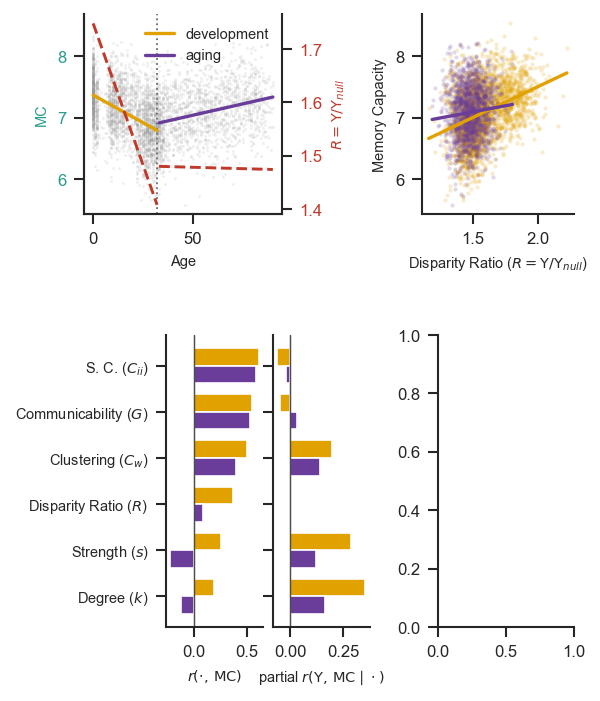

In [37]:
fig = plt.figure(figsize=(3.4, 4.75))

gtop = fig.add_gridspec(1, 2, left=0.02, right=0.98, top=0.95, bottom=0.67, wspace=0.8, width_ratios=[1.3,1])
gbot = fig.add_gridspec(1, 2, left=0.18, right=0.98, top=0.50, bottom=0.09, wspace=0.4, width_ratios=[1.5,1])

axU = fig.add_subplot(gtop[0, 0])
axB = fig.add_subplot(gtop[0, 1])
gcd = gbot[0, 0].subgridspec(1, 2, wspace=0.1)
axH = fig.add_subplot(gcd[0]); axE = fig.add_subplot(gcd[1], sharey=axH)
axS = fig.add_subplot(gbot[0, 1])

dev_df = df[df["cohort"]=="development"]; age_df = df[df["cohort"]=="aging"]

# (a) MC and disparity across the lifespan -- exact-age fits, no binning
df_mc = df.dropna(subset=["MC", "age"])
df_kY = df.dropna(subset=["Ratio", "age"])
axU.scatter(df_mc["age"], df_mc["MC"], s=2, alpha=0.15, color="0.6", linewidths=0, zorder=1)
for coh, col in COHORT_COL.items():
    sub = df_mc[df_mc["cohort"] == coh]
    b = np.polyfit(sub["age"], sub["MC"], 1)
    xs = np.linspace(sub["age"].min(), sub["age"].max(), 100)
    axU.plot(xs, np.polyval(b, xs), color=col, lw=1.6, zorder=5, label=coh)
axU.set_ylabel("MC", color=COL["mc"])
axU.tick_params(axis="y", labelcolor=COL["mc"])
axU.set_xlabel("Age")
axU.axvline(AGE_SPLIT, color="0.45", ls=":", lw=0.9, zorder=2)
axU.legend(fontsize=7, frameon=False, loc="upper right")

ax2 = axU.twinx()
for coh in ("development", "aging"):
    sub = df_kY[df_kY["cohort"] == coh]
    b = np.polyfit(sub["age"], sub["Ratio"], 1)
    xs = np.linspace(sub["age"].min(), sub["age"].max(), 100)
    ax2.plot(xs, np.polyval(b, xs), color=COL["disp"], lw=1.4, ls="--", zorder=4)
ax2.set_ylabel(r"$R=\Upsilon/\Upsilon_{null}$", color=COL["disp"])
ax2.tick_params(axis="y", labelcolor=COL["disp"])
ax2.spines["right"].set_visible(True)

# (b) MC vs disparity by regime
for coh in ("development", "aging"):
    d = df[df["cohort"]==coh].dropna(subset=["Ratio","MC"]); c = COHORT_COL[coh]
    axB.scatter(d["Ratio"], d["MC"], s=4, alpha=0.20, color=c, lw=0)
    if len(d) > 10:
        b = np.polyfit(d["Ratio"], d["MC"], 1)
        xs = np.linspace(d["Ratio"].min(), d["Ratio"].max(), 50)
        axB.plot(xs, np.polyval(b, xs), color=c, lw=1.6, label=coh)
axB.set_xlabel(r"Disparity Ratio ($R=\Upsilon/\Upsilon_{null}$)"); axB.set_ylabel("Memory Capacity")

# métricas y orden compartidos por (c) y (d)
preds = [("Ratio", r"Disparity Ratio ($R$)"), ("comm_mean", r"Communicability ($G$)"),
         ("C_w", r"Clustering ($C_w$)"), ("self_comm_mean", r"S. C. ($C_{ii}$)"),
         ("strength", r"Strength ($s$)"), ("degree", r"Degree ($k$)")]
preds = [(c, l) for c, l in preds if c in df.columns]

rc = []
for c, l in preds:
    rd_, _ = pearson_p(dev_df[c], dev_df["MC"]); ra_, _ = pearson_p(age_df[c], age_df["MC"])
    rc.append([c, l, rd_, ra_])
rc.sort(key=lambda t: abs(t[2]) if np.isfinite(t[2]) else 0)
order = [t[0] for t in rc]; lab = {c: l for c, l in preds}
y = np.arange(len(rc)); h = 0.38

# (c)+(d) comparten eje-y dentro de la celda inferior izquierda

# (c) r(metric, MC) by regime
axH.barh(y + h/2, [t[2] for t in rc], h, color=COL["dev"], label="development")
axH.barh(y - h/2, [t[3] for t in rc], h, color=COL["aging"], label="aging")
axH.axvline(0, color="0.3", lw=0.7)
axH.set_yticks(y); axH.set_yticklabels([t[1] for t in rc], fontsize=7)
axH.set_xlabel(r"$r(\cdot,\,\mathrm{MC})$")

# (d) partial r(Y, MC | metric)
def _pr(frame, cov):
    if cov == "Ratio":
        return np.nan
    return partial_r(frame["Ratio"], frame["MC"], frame[cov])[0]
dv = [_pr(dev_df, c) for c in order]; av = [_pr(age_df, c) for c in order]
axE.barh(y + h/2, dv, h, color=COL["dev"])
axE.barh(y - h/2, av, h, color=COL["aging"])
axE.axvline(0, color="0.3", lw=0.7)
axE.legend(loc="center right", frameon=False, fontsize=5.5)
plt.setp(axE.get_yticklabels(), visible=False)
axE.set_xlabel(r"partial $r(\Upsilon,\,\mathrm{MC}\mid\cdot)$", fontsize=7)

# (e) weight surrogates
surr_order = ["Real","Uniform", "BrokenStick", "Reshuffle",  "SignFlip"]
surr_pal   = {"Real": COL["mc"], "BrokenStick": COL["disp"], "Reshuffle": COL["comm"],
              "Uniform": COL["null"], "SignFlip": "#7F8C8D"}

# Include "Real" in your mapping just to be safe
surr_labels = {"Real": "Real", "BrokenStick": "Broken Stick", "Reshuffle": "Reshuffle", 
               "Uniform": "Uniform", "SignFlip": "Sign Flip"}

sm = surr.groupby(["subject_id", "model"])["MC"].mean().reset_index()

# Remove the invalid 'labels' argument here
D = pd.DataFrame({m: wide[m] - wide["Real"] for m in nulls}).reset_index()
Dlong = D.melt(id_vars="subject_id", var_name="model", value_name="dMC")

sns.boxplot(data=Dlong, x="model", y="dMC", order=nulls,
            palette={m: surr_pal[m] for m in nulls}, ax=axS, showfliers=False)
axS.axhline(0, ls="--", lw=0.8, color=COL["mc"])     # Real = baseline
axS.set_ylabel(r"$\Delta$MC (null $-$ real)"); axS.set_xlabel("")

# Extract current tick texts, map them through your dictionary, and set them
new_labels = [surr_labels.get(tick.get_text(), tick.get_text()) for tick in axS.get_xticklabels()]
axS.set_xticklabels(new_labels, rotation=50, ha="right", fontsize=7)

# panel labels
for ax, L in zip([axU, axB, axH, axE, axS], "abcde"):
    ax.text(-0.15, 1.1, L, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top', ha='right')


save_fig(fig, "figure1_mc_predictors"); plt.show()

In [38]:
from scipy.stats import wilcoxon

wide  = sm.pivot(index="subject_id", columns="model", values="MC")
nulls = ["Uniform", "BrokenStick", "Reshuffle", "SignFlip"]

for m in nulls:
    d = (wide[m] - wide["Real"]).dropna()
    w, p = wilcoxon(d)
    print(f"{m:12s} median ΔMC = {d.median():+.3f}   p = {p:.2e}   n = {len(d)}")

Uniform      median ΔMC = -0.732   p = 4.67e-18   n = 100
BrokenStick  median ΔMC = -0.228   p = 3.82e-10   n = 100
Reshuffle    median ΔMC = +0.282   p = 2.34e-15   n = 100
SignFlip     median ΔMC = +0.171   p = 2.45e-10   n = 100


## 6 · Figure 2 — communicability decomposition, regime change, multivariate picture

(a) The Taylor validation: pooled over nodes and subjects, the exact self-communicability
$C_{ii}=(e^{W})_{ii}$ against its order-2 approximation $1+\tfrac12(W^2)_{ii}=1+\tfrac12 s_i^2 Y_i$
(disparity); the inset shows the order-3 term tracking weighted clustering. (b) The R²
decomposition of MC (Table III) for development vs aging — Υ alone collapses in aging
while Υ+$C_w$ and Υ+$T_3$ stay near 0.45: the heterogeneity→triangle regime change.
(c) A PCA of the coupled family (Υ, $C_w$, $G$, MC, age). (d) Their correlation matrix.

In [39]:
# === Figure 4 · bin-free recompute ==========================================
def segmented_breakpoint(age, y, n_grid=60, n_boot=250, seed=SEED):
    """Continuous two-segment (broken-stick) regression. Returns the crossover
    age tau (a free model parameter, no binning) with bootstrap 95% CI.
    Model:  y = a + b*age + c*max(age - tau, 0);  tau chosen by least squares."""
    age, y = np.asarray(age, float), np.asarray(y, float)
    m = np.isfinite(age) & np.isfinite(y); age, y = age[m], y[m]
    grid = np.linspace(np.percentile(age, 5), np.percentile(age, 95), n_grid)
    def _tau(a, v):
        best_t, best_sse = grid[0], np.inf
        for t in grid:
            X = np.column_stack([np.ones_like(a), a, np.maximum(a - t, 0.0)])
            beta, *_ = np.linalg.lstsq(X, v, rcond=None)
            sse = float(((v - X @ beta) ** 2).sum())
            if sse < best_sse: best_sse, best_t = sse, t
        return best_t
    tau = _tau(age, y); rng = np.random.default_rng(seed); n = len(age)
    bs = np.array([_tau(age[i], y[i]) for i in (rng.integers(0, n, n) for _ in range(n_boot))])
    return tau, np.percentile(bs, 2.5), np.percentile(bs, 97.5)

MOUSLEY_TP = 32.0
tps = {}
for col, lab in [("MC", "MC (function)"), ("self_comm_mean", r"$C_{ii}$ (structure)")]:
    if col in df.columns:
        tps[lab] = segmented_breakpoint(df["age"].values, df[col].values)
        p, lo, hi = tps[lab]; print(f"{lab:<22} breakpoint = {p:.1f}  [{lo:.1f}, {hi:.1f}]")

# PCA of the structure-function family; cohort centroids replace the binned arc
fam = {"Ratio": r"$\Upsilon$", "C_w": r"$C_w$", "comm_mean": r"$G$",
       "self_comm_mean": r"$C_{ii}$", "MC": "MC"}
fcols = [c for c in fam if c in df.columns]
Pf = df.dropna(subset=fcols + ["age", "cohort"]).copy()
Xf = (Pf[fcols].values - Pf[fcols].values.mean(0)) / Pf[fcols].values.std(0)
Up, Sp, Vtp = np.linalg.svd(Xf - Xf.mean(0), full_matrices=False)
ev = (Sp**2) / (Sp**2).sum(); scores = Up[:, :2] * Sp[:2]; load = Vtp[:2].T
cen = {coh: scores[(Pf["cohort"] == coh).values].mean(0) for coh in ("development", "aging")}

MC (function)          breakpoint = 29.1  [27.8, 29.1]
$C_{ii}$ (structure)   breakpoint = 26.4  [25.1, 27.8]


In [40]:
# === Table: C_ii vs its walk terms =========================================
Pv  = df.dropna(subset=["self_comm_mean","T2_mean","T3_mean","comm_mean","C_w"]).copy()
Cii = Pv["self_comm_mean"].values
recon = {"order 0 (1)":            np.ones_like(Cii),
         "order 2 (1+T2)":         1 + Pv["T2_mean"].values,
         "order 3 (1+T2+T3)":      1 + Pv["T2_mean"].values + Pv["T3_mean"].values}
for k, x in recon.items():
    r2 = 0.0 if np.std(x) == 0 else pearson_p(x, Cii)[0]**2
    print(f"  {k:<20} R2(C_ii, .) = {r2:.4f}")
print(f"  total comm. G        R2(C_ii, G) = {pearson_p(Pv['comm_mean'].values, Cii)[0]**2:.4f}")
print(f"  r(T3, C_w)           = {pearson_p(Pv['T3_mean'].values, Pv['C_w'].values)[0]:.3f}")

  order 0 (1)          R2(C_ii, .) = 0.0000
  order 2 (1+T2)       R2(C_ii, .) = 0.9985
  order 3 (1+T2+T3)    R2(C_ii, .) = 0.9998
  total comm. G        R2(C_ii, G) = 0.8334
  r(T3, C_w)           = 0.817


In [81]:
# === Fig. manifold — computation ===========================================
from scipy.ndimage import gaussian_filter1d

ecols = ["Ratio", "C_w", "self_comm_mean", "s2n_mean"]   # 3 structural + normalised strength
flab  = {"Ratio": r"$R$", "C_w": r"$C_w$", "self_comm_mean": r"$C_{ii}$",
         "s2n_mean": r"$\tilde s^{2}$", "MC": "MC"}
arrow_vars = ecols + ["MC"]                              # MC = supplementary arrow only
# MC = supplementary arrow (not embedded)
#arrow_vars = ecols                                        # all arrows from embedded vars

Pf   = df.dropna(subset=ecols + ["age", "MC", "cohort"]).copy()
Xf   = (Pf[ecols].values - Pf[ecols].values.mean(0)) / Pf[ecols].values.std(0)
ages = Pf["age"].values; mcv = Pf["MC"].values

cl = {v: np.array([np.corrcoef(Pf[v].values, scores[:, k])[0, 1] for k in (0, 1)])
      for v in arrow_vars}
for coh in ("development", "aging"):
    m = (Pf["cohort"] == coh).values
    print(f"r(Upsilon, MC)  {coh:<12} = {np.corrcoef(Pf['Ratio'].values[m], Pf['MC'].values[m])[0,1]:+.2f}")


# PCA (shared)
Up, Sp, _ = np.linalg.svd(Xf - Xf.mean(0), full_matrices=False)
ev     = (Sp**2) / (Sp**2).sum()
scores = Up[:, :2] * Sp[:2]
if np.corrcoef(scores[:, 0], ages)[0, 1] < 0: scores[:, 0] *= -1     # PC1 grows with age
if np.corrcoef(scores[:, 1], mcv)[0, 1]  < 0: scores[:, 1] *= -1     # PC2 grows with MC

# per-cohort arrow directions: corr(variable, PC) within cohort (MC included, supplementary)
dirs = {coh: {v: np.array([np.corrcoef(Pf[v].values[(Pf["cohort"]==coh).values],
                                        scores[(Pf["cohort"]==coh).values,k])[0,1] for k in (0,1)])
              for v in arrow_vars} for coh in ("development","aging")}   # per-cohort loadings -> arcs
cl   = {v: np.array([np.corrcoef(Pf[v].values, scores[:,k])[0,1] for k in (0,1)]) for v in arrow_vars}  # pooled
                               # PCA·MC trajectory

# per-cohort variance along the shared PCs (small table)
allsc = Up * Sp
vexp  = {c: allsc[(Pf["cohort"] == c).values][:, :2].var(0)
            / allsc[(Pf["cohort"] == c).values].var(0).sum() for c in ("development", "aging")}
print(f"global     PC1={ev[0]*100:4.1f}%  PC2={ev[1]*100:4.1f}%")
for c in ("development", "aging"):
    print(f"{c:<11} PC1={vexp[c][0]*100:4.1f}%  PC2={vexp[c][1]*100:4.1f}%")

# UMAP (defaults, no sweep)
ump = umap.UMAP(random_state=SEED).fit_transform(Xf) if HAS_UMAP else scores.copy()

def var_path(coords, v, nq=24, sigma=1.5):
    q  = np.quantile(v, np.linspace(0, 1, nq + 1))
    b  = np.clip(np.digitize(v, q[1:-1]), 0, nq - 1)
    ks = [k for k in range(nq) if (b == k).any()]
    cx = np.array([coords[b == k, 0].mean() for k in ks])
    cy = np.array([coords[b == k, 1].mean() for k in ks])
    return cx, cy, gaussian_filter1d(cx, sigma), gaussian_filter1d(cy, sigma)

path = {("pca","age"): var_path(scores, ages),
        ("ump","age"): var_path(ump,    ages),
        ("ump","MC"):  var_path(ump,    mcv),
        ("pca","MC"):  var_path(scores, mcv)}

r(Upsilon, MC)  development  = +0.37
r(Upsilon, MC)  aging        = +0.09
global     PC1=74.2%  PC2=19.6%
development PC1=80.0%  PC2=14.5%
aging       PC1=64.9%  PC2=26.2%


saved figures\figure4_manifold_withstrength.[pdf|png]


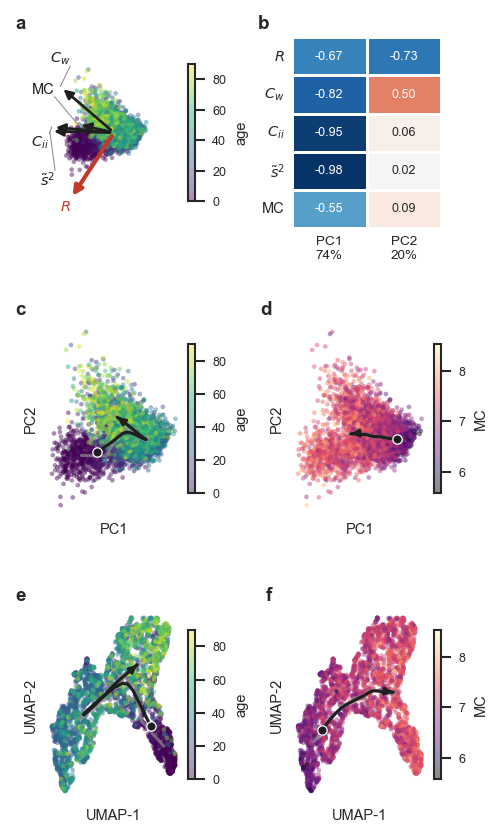

In [82]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import pandas as pd

amin, amax = ages.min(), ages.max(); mmin, mmax = mcv.min(), mcv.max()
fig = plt.figure(figsize=(3.4, 6.6))
g   = fig.add_gridspec(3, 2, wspace=0.65, hspace=0.5)

def traj(ax, cx, cy, sx, sy, lw=1.5):
    ax.plot(cx, cy, color="0.55", lw=lw, alpha=0.7, zorder=5)
    ax.plot(sx, sy, color="0.12", lw=lw, zorder=6)
    ax.annotate("", xy=(sx[-1], sy[-1]), xytext=(sx[-2], sy[-2]),
                arrowprops=dict(arrowstyle="-|>", color="0.12", lw=lw), zorder=7)
    ax.scatter([sx[0]], [sy[0]], s=20, color="0.12", ec="white", lw=0.6, zorder=8)


# (a) biplot: age-coloured scores (the lifespan U-arc) + loading arrows
axa = fig.add_subplot(g[0, 0])
arrow_vars = list(dict.fromkeys(arrow_vars))           # remove duplicate MC
S = np.asarray(scores)[:, :2]*0.5
L = {v: np.asarray(cl[v][:2], float) for v in arrow_vars}
span = np.percentile(np.abs(S), 98)*2
asc  = 0.95*span / max(np.hypot(*L[v]) for v in arrow_vars)   # scale arrows to cloud

sca = axa.scatter(S[:, 0], S[:, 1], c=ages, cmap="viridis", vmin=amin, vmax=amax,
                  s=5, alpha=0.45, lw=0, rasterized=True, zorder=1)
tips = []
for v in arrow_vars:
    x, y = L[v]*asc; hot = (v == "Ratio")
    axa.annotate("", xy=(x, y), xytext=(0, 0), zorder=6,
                 arrowprops=dict(arrowstyle="-|>", color=COL["disp"] if hot else "0.12",
                                 lw=2.0 if hot else 1.3, mutation_scale=9))
    tips.append((x, y))

# de-collided labels on the perimeter, leader lines to the arrow tips
tips = np.asarray(tips, float)
ang = np.degrees(np.arctan2(tips[:, 1], tips[:, 0]))
order = np.argsort(ang); a = ang[order].astype(float)
R_lab, min_sep = span*0.95, 24.0                       # knobs: radius / spread
for _ in range(500):
    moved = False
    for i in range(len(a) - 1):
        gap = a[i+1] - a[i]
        if gap < min_sep:
            d = (min_sep - gap) / 2; a[i] -= d; a[i+1] += d; moved = True
    if not moved: break
anchor = np.empty(len(tips)); anchor[order] = a

for (x, y), thl, v in zip(tips, np.radians(anchor), arrow_vars):
    hot = (v == "Ratio"); lx, ly = R_lab*np.cos(thl), R_lab*np.sin(thl)
    if lx > span * 0.80:                         # clamp rightward labels inside xlim
        f = span * 0.80 / lx; lx *= f; ly *= f
    axa.plot([x, lx], [y, ly], color="0.55", lw=0.5, zorder=5)
    axa.text(lx, ly, flab[v], fontsize=7, ha="left" if lx >= 0 else "right",
             va="bottom" if ly >= 0 else "top",
             color=COL["disp"] if hot else "0.12",
             fontweight="bold" if hot else "normal", zorder=8)

lim = span
axa.set_xlim(-lim, lim); axa.set_ylim(-lim, lim)
axa.set_xticks([]); axa.set_yticks([]); sns.despine(ax=axa, left=True, bottom=True)
cb = fig.colorbar(sca, ax=axa, fraction=0.046, pad=0.04)
cb.set_label("age", fontsize=7); cb.ax.tick_params(labelsize=6)


# (b) two components in matrix form (correlation loadings; % = variance explained)
axb = fig.add_subplot(g[0, 1])
Lmat = pd.DataFrame({"PC1": [cl[v][0] for v in arrow_vars], "PC2": [cl[v][1] for v in arrow_vars]},
                    index=[flab[v] for v in arrow_vars])
sns.heatmap(Lmat, ax=axb, cmap="RdBu_r", vmin=-1, vmax=1, center=0, cbar=False,
            annot=True, fmt=".2f", annot_kws={"size": 6}, linewidths=0.5, linecolor="white")
axb.set_xticklabels([f"PC1\n{ev[0]*100:.0f}%", f"PC2\n{ev[1]*100:.0f}%"], rotation=0, fontsize=6.5)
axb.set_yticklabels(axb.get_yticklabels(), rotation=0, fontsize=7); axb.tick_params(length=0)

# (c) PCA·age   (d) PCA·MC
axc = fig.add_subplot(g[1, 0])
scc = axc.scatter(scores[:,0], scores[:,1], c=ages, cmap="viridis", vmin=amin, vmax=amax, s=5, alpha=0.45, lw=0, rasterized=True)
traj(axc, *path[("pca","age")]); axc.set_xlabel("PC1"); axc.set_ylabel("PC2"); sns.despine(ax=axc)
cb = fig.colorbar(scc, ax=axc, fraction=0.05, pad=0.04); cb.set_label("age", fontsize=7); cb.ax.tick_params(labelsize=6)
axd = fig.add_subplot(g[1, 1])
scd = axd.scatter(scores[:,0], scores[:,1], c=mcv, cmap="magma", vmin=mmin, vmax=mmax, s=5, alpha=0.45, lw=0, rasterized=True)
traj(axd, *path[("pca","MC")]); axd.set_xlabel("PC1"); axd.set_ylabel("PC2"); sns.despine(ax=axd)
cb = fig.colorbar(scd, ax=axd, fraction=0.05, pad=0.04); cb.set_label("MC", fontsize=7); cb.ax.tick_params(labelsize=6)
sns.despine(ax=axd, left=True, bottom=True), sns.despine(ax=axc, left=True, bottom=True)
axc.set_xticks([]); axc.set_yticks([]); axd.set_xticks([]); axd.set_yticks([])


# (e) UMAP·age   (f) UMAP·MC
axe = fig.add_subplot(g[2, 0])
sce = axe.scatter(ump[:,0], ump[:,1], c=ages, cmap="viridis", vmin=amin, vmax=amax, s=5, alpha=0.45, lw=0, rasterized=True)
traj(axe, *path[("ump","age")]); axe.set_xlabel("UMAP-1"); axe.set_ylabel("UMAP-2")
axe.set_xticks([]); axe.set_yticks([]); sns.despine(ax=axe, left=True, bottom=True)
cb = fig.colorbar(sce, ax=axe, fraction=0.05, pad=0.04); cb.set_label("age", fontsize=7); cb.ax.tick_params(labelsize=6)
axf = fig.add_subplot(g[2, 1])
scf = axf.scatter(ump[:,0], ump[:,1], c=mcv, cmap="magma", vmin=mmin, vmax=mmax, s=5, alpha=0.45, lw=0, rasterized=True)
traj(axf, *path[("ump","MC")]); axf.set_xlabel("UMAP-1"); axf.set_ylabel("UMAP-2")
axf.set_xticks([]); axf.set_yticks([]); sns.despine(ax=axf, left=True, bottom=True)
cb = fig.colorbar(scf, ax=axf, fraction=0.05, pad=0.04); cb.set_label("MC", fontsize=7); cb.ax.tick_params(labelsize=6)

for ax, L in zip([axa, axb, axc, axd, axe, axf], "abcdef"):
    ax.text(-0.15, 1.12, L, transform=ax.transAxes, fontsize=9, fontweight="bold", va="top", ha="right")

save_fig(fig, "figure4_manifold_withstrength"); plt.show()

In [45]:
import numpy as np
for k in (0, 1):
    print(f"PC{k+1}: r(age)={np.corrcoef(scores[:,k], ages)[0,1]:+.2f}  r(MC)={np.corrcoef(scores[:,k], mcv)[0,1]:+.2f}")

PC1: r(age)=+0.21  r(MC)=-0.75
PC2: r(age)=+0.49  r(MC)=+0.24


## 7 · Secondary and supplementary panels

The surrogate, biological-input and IPC controls, the Mijalkov thresholding contrast, and
the extended PCA/UMAP multivariate analysis. These support the main text and live in the
supplement.

### 7a · Surrogate and biological-input controls, IPC orders

saved figures\supp_controls.[pdf|png]


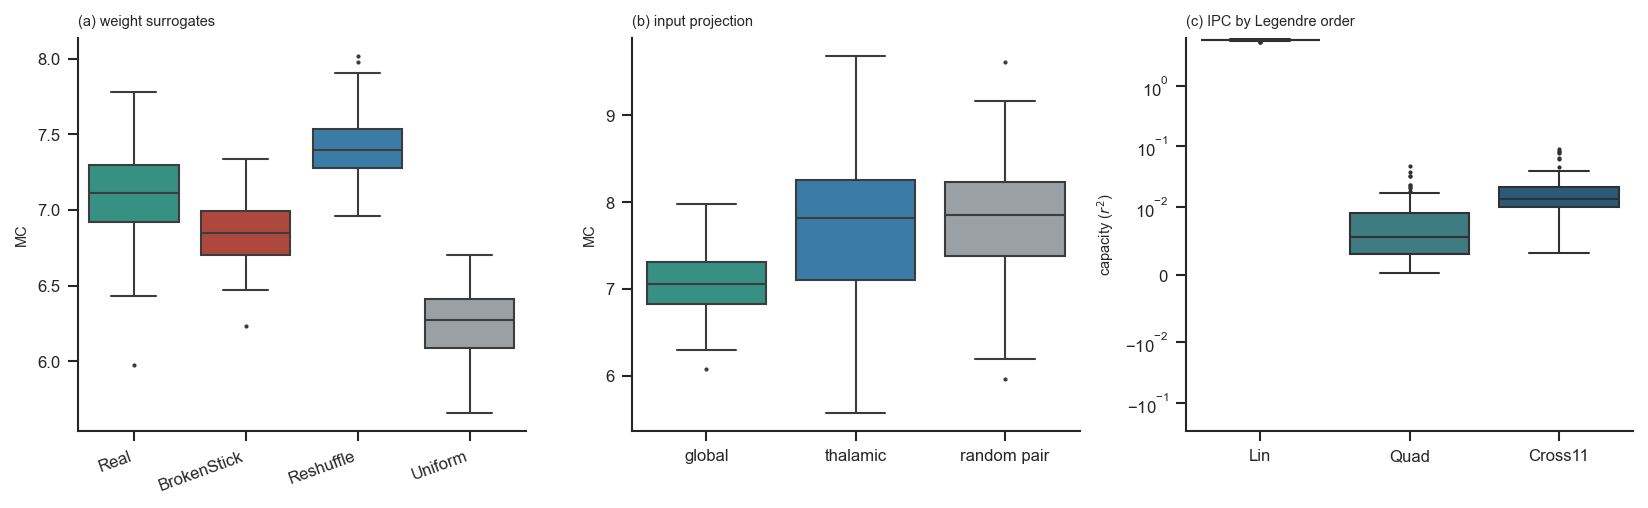

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

# surrogate boxplots
order = ["Real","BrokenStick","Reshuffle","Uniform"]
pal = {"Real":COL["mc"], "BrokenStick":COL["disp"], "Reshuffle":COL["comm"], "Uniform":COL["null"]}
sm = surr.groupby(["subject_id","model"])["MC"].mean().reset_index()
sns.boxplot(data=sm, x="model", y="MC", order=order, palette=pal, ax=axes[0], fliersize=1)
axes[0].set_title("(a) weight surrogates", fontsize=7, loc="left")
axes[0].set_xlabel(""); axes[0].set_ylabel("MC")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")

# bio boxplots
bm = bio.melt(id_vars="subject_id", value_vars=["MC","MC_Bio","MC_BioNull"],
              var_name="input", value_name="mc")
lbl = {"MC":"global","MC_Bio":"thalamic","MC_BioNull":"random pair"}
bm["input"] = bm["input"].map(lbl)
sns.boxplot(data=bm, x="input", y="mc", ax=axes[1], fliersize=1,
            palette=[COL["mc"], COL["comm"], COL["null"]])
axes[1].set_title("(b) input projection", fontsize=7, loc="left")
axes[1].set_xlabel(""); axes[1].set_ylabel("MC")

# IPC orders
ipc_cols = [c for c in ipc.columns if c != "subject_id"]
im = ipc.melt(id_vars="subject_id", value_vars=ipc_cols, var_name="order", value_name="cap")
sns.boxplot(data=im, x="order", y="cap", ax=axes[2], fliersize=1,
            palette=sns.color_palette("crest", len(ipc_cols)))
axes[2].set_yscale("symlog", linthresh=1e-2)
axes[2].set_title("(c) IPC by Legendre order", fontsize=7, loc="left")
axes[2].set_xlabel(""); axes[2].set_ylabel("capacity ($r^2$)")

fig.tight_layout(); save_fig(fig, "supp_controls"); plt.show()


### 7b · Mijalkov contrast — thresholded camCAN

Mijalkov et al. (2025) report MC *decreasing* with age using FA-weighted, thresholded
networks on camCAN. We cannot reproduce FA, but we can test whether **proportional
thresholding** of the camCAN streamline-count connectomes flips our macroscopic result.
We threshold camCAN to density 0.15, recompute MC, and correlate with age.

saved figures\supp_mijalkov_camcan.[pdf|png]


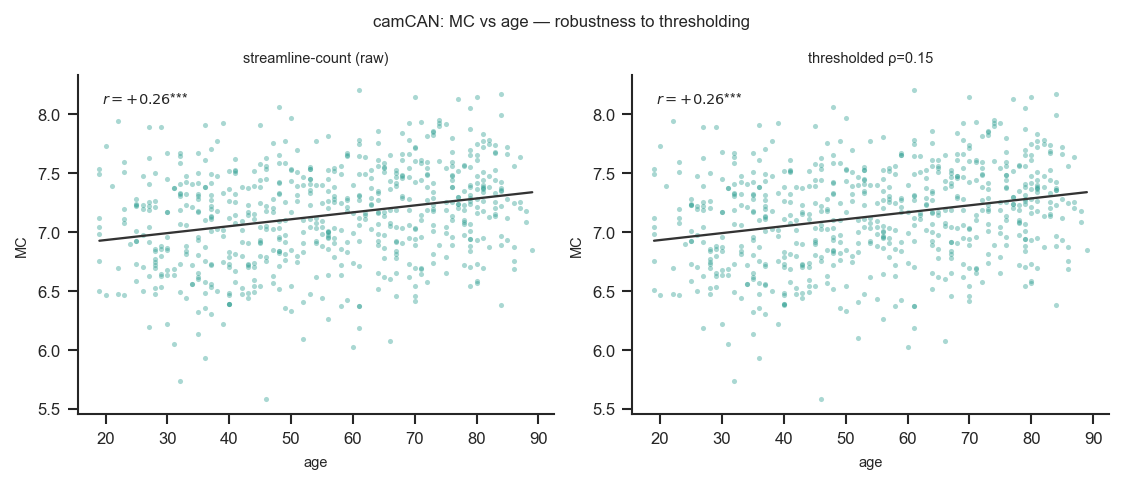

In [29]:
camcan = df[df["dataset"] == CAMCAN_DS].copy()
if len(camcan) >= 10:
    thr_cache = WORK_DIR / "mc_camcan_thr.pkl"
    if thr_cache.exists() and not FORCE_RECOMPUTE:
        mc_thr = pd.read_pickle(thr_cache)
    else:
        # export thresholded camCAN connectomes, run the workhorse on them
        path = CPP_DATA / "connectomes_camcan_thr.csv"
        with open(path, "w") as f:
            f.write("subject_id," + ",".join(f"w{k}" for k in range(N_NODES*N_NODES)) + "\n")
            for sid, A in zip(camcan["sid"], camcan["connectome"]):
                M = proportional_threshold(_mat(A), 0.15).flatten()
                f.write(f"{int(sid)}," + ",".join(f"{v:.6g}" for v in M) + "\n")
        write_config("cfg_mc_thr.txt", **RES, **MAIN, seed=SEED, threads=N_THREADS,
                     in_csv="data/connectomes_camcan_thr.csv", out_csv="mc_camcan_thr.csv")
        run_program("esn_mc", "cfg_mc_thr.txt", EXE)
        mc_thr = pd.read_csv("mc_camcan_thr.csv").rename(columns={"MC_Glob":"MC_thr"})
        mc_thr.to_pickle(thr_cache)
    camcan = camcan.merge(mc_thr.rename(columns={"subject_id":"sid"}), on="sid", how="left")

    fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.2))
    for a,(col,lab) in zip(ax, [("MC","streamline-count (raw)"), ("MC_thr","thresholded ρ=0.15")]):
        if col not in camcan: continue
        a.scatter(camcan["age"], camcan[col], s=6, color=COL["mc"], alpha=0.4, lw=0)
        b = np.polyfit(camcan["age"], camcan[col], 1); xs = np.linspace(camcan["age"].min(), camcan["age"].max(), 30)
        a.plot(xs, np.polyval(b, xs), color="0.2", lw=1.1)
        r,p = pearson_p(camcan["age"], camcan[col])
        a.text(0.05, 0.95, f"$r={r:+.2f}${sig_stars(p)}", transform=a.transAxes, va="top", fontsize=7)
        a.set_xlabel("age"); a.set_ylabel("MC"); a.set_title(lab, fontsize=7)
    fig.suptitle("camCAN: MC vs age — robustness to thresholding", fontsize=8)
    fig.tight_layout(); save_fig(fig, "supp_mijalkov_camcan"); plt.show()
else:
    print("camCAN subset too small for the thresholding contrast.")


### 7c · Extended PCA and UMAP (supplementary multivariate analysis)

In [30]:
# PCA global propio (la celda ya no depende de la antigua Figura 2)
_pcols = [("Ratio",r"$\Upsilon$"), ("C_w","$C_w$"), ("comm_mean","$G$"),
          ("self_comm_mean","$C_{ii}$"), ("MC","MC")]
pca_cols = [(c,l) for c,l in _pcols if c in df.columns]
P = df.dropna(subset=[c for c,_ in pca_cols]+["age"]).copy()
_X = P[[c for c,_ in pca_cols]].values
Xs = (_X - _X.mean(0)) / _X.std(0)
_U, S, Vt = np.linalg.svd(Xs - Xs.mean(0), full_matrices=False)
scores = _U[:, :2] * S[:2]; ev = (S**2)/(S**2).sum()

saved figures\supp_pca_umap.[pdf|png]


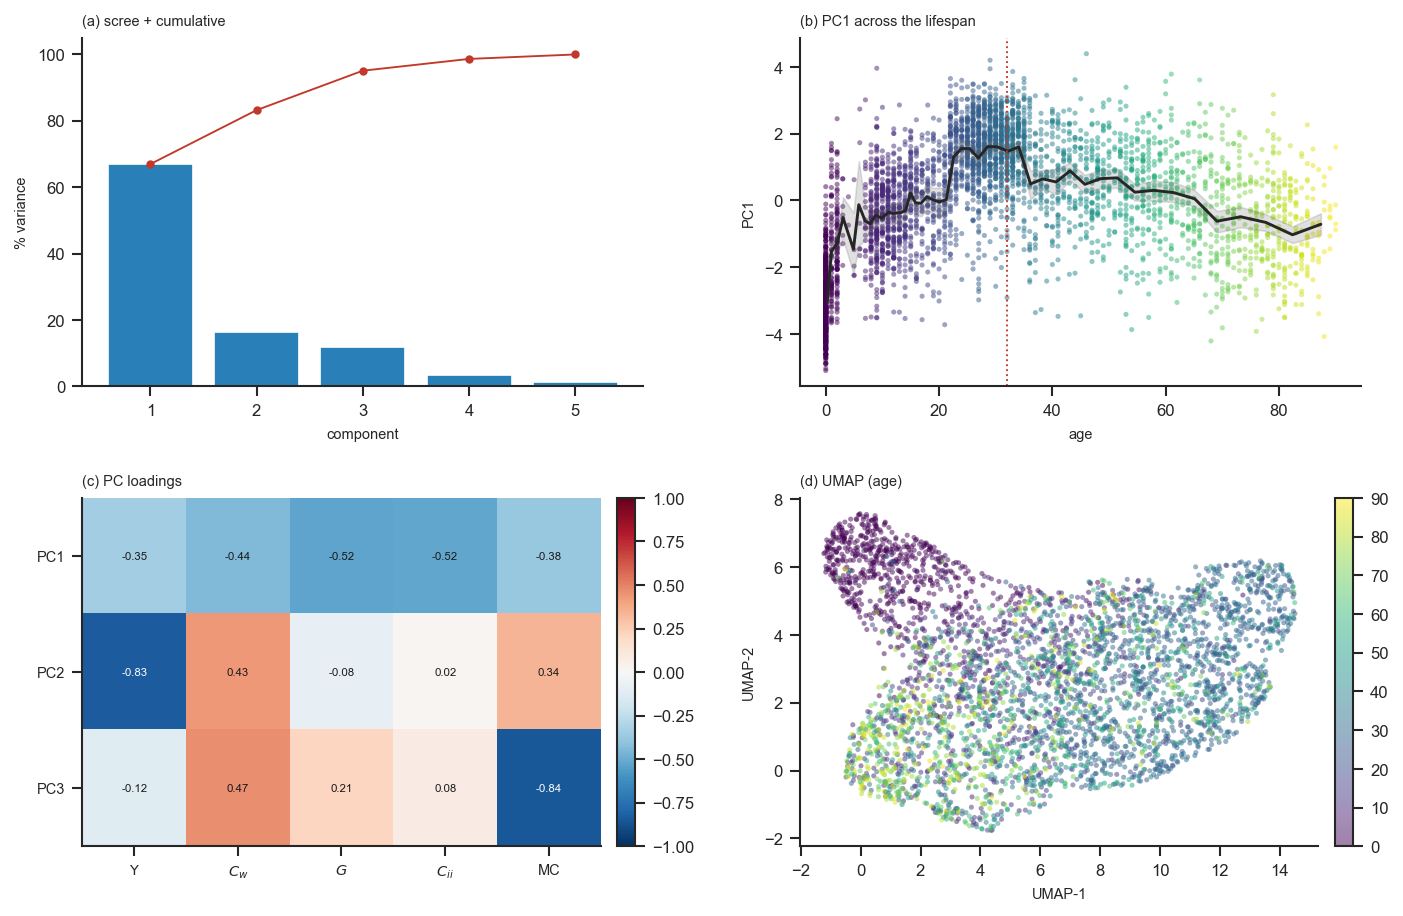

In [31]:
fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.28)

# scree
axs = fig.add_subplot(gs[0,0])
axs.bar(np.arange(1, len(ev)+1), ev*100, color=COL["comm"])
axs.plot(np.arange(1, len(ev)+1), np.cumsum(ev)*100, "o-", color=COL["accent"], ms=3)
axs.set_xlabel("component"); axs.set_ylabel("% variance"); axs.set_xticks(range(1,len(ev)+1))
axs.set_title("(a) scree + cumulative", fontsize=7, loc="left")

# PC1 vs age (the fold / turning point)
axf = fig.add_subplot(gs[0,1])
axf.scatter(P["age"], scores[:,0], c=P["age"], cmap="viridis", s=6, alpha=0.5, lw=0, rasterized=True)
cen, mean, lo, hi = binned_trajectory(P["age"].values, scores[:,0])
axf.plot(cen, mean, color="0.15", lw=1.4); axf.fill_between(cen, lo, hi, color="0.4", alpha=0.2)
axf.axvline(AGE_SPLIT, color=COL["accent"], ls=":", lw=0.9)
axf.set_xlabel("age"); axf.set_ylabel("PC1"); axf.set_title("(b) PC1 across the lifespan", fontsize=7, loc="left")

# loadings heatmap PC1-3
axl = fig.add_subplot(gs[1,0])
nL = min(3, Vt.shape[0]); L = Vt[:nL]
im = axl.imshow(L, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axl.set_xticks(range(len(pca_cols))); axl.set_xticklabels([l for _,l in pca_cols], fontsize=7)
axl.set_yticks(range(nL)); axl.set_yticklabels([f"PC{i+1}" for i in range(nL)], fontsize=7)
for i in range(nL):
    for j in range(len(pca_cols)):
        axl.text(j, i, f"{L[i,j]:.2f}", ha="center", va="center", fontsize=5.5,
                 color="white" if abs(L[i,j])>0.55 else "0.1")
axl.set_title("(c) PC loadings", fontsize=7, loc="left")
fig.colorbar(im, ax=axl, fraction=0.046, pad=0.03)

# UMAP (or PC1-PC2 by dataset fallback)
axu = fig.add_subplot(gs[1,1])
if HAS_UMAP:
    emb = umap.UMAP(n_neighbors=25, min_dist=0.3, random_state=SEED).fit_transform(Xs)
    scu = axu.scatter(emb[:,0], emb[:,1], c=P["age"], cmap="viridis", s=6, alpha=0.5, lw=0, rasterized=True)
    axu.set_xlabel("UMAP-1"); axu.set_ylabel("UMAP-2"); axu.set_title("(d) UMAP (age)", fontsize=7, loc="left")
    fig.colorbar(scu, ax=axu, fraction=0.046, pad=0.03)
else:
    for d in sorted(P["dataset"].unique()):
        m = P["dataset"] == d
        axu.scatter(scores[m,0], scores[m,1], s=6, alpha=0.5, lw=0,
                    color=DS_PALETTE.get(int(d)), label=DS_NAMES.get(int(d), str(d)))
    axu.legend(frameon=False, fontsize=5, ncol=2, loc="best")
    axu.set_xlabel("PC1"); axu.set_ylabel("PC2")
    axu.set_title("(d) PC1–PC2 by dataset (install umap-learn for UMAP)", fontsize=7.5, loc="left")

save_fig(fig, "supp_pca_umap"); plt.show()


In [75]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path

def _pagerank(A, alpha=0.85, iters=300, tol=1e-10):
    N = A.shape[0]; out_str = A.sum(0)
    M = np.divide(A, out_str, out=np.zeros_like(A), where=out_str > 0)  # column-stochastic
    dangling = (out_str == 0).astype(float)
    r = np.full(N, 1.0/N)
    for _ in range(iters):
        rn = (1-alpha)/N + alpha*(M @ r) + alpha*(dangling @ r)/N
        rn /= rn.sum()
        if np.abs(rn - r).sum() < tol: r = rn; break
        r = rn
    return r

def nodal_metrics_all(A, rho=RHO):
    A = _mat(A); N = A.shape[0]
    s = A.sum(1); k = (A > 0).sum(1).astype(float)
    out = {}

    # --- weight distribution ---
    with np.errstate(divide="ignore", invalid="ignore"):
        P = np.where(s[:, None] > 0, A / s[:, None], 0.0)
    Y = (P**2).sum(1)
    out["strength"], out["degree"], out["disparity_Y"], out["kY"] = s, k, Y, k*Y
    with np.errstate(divide="ignore", invalid="ignore"):
        Ynull = np.where(k > 0, 2.0/(k+1.0), np.nan)
        out["ratio"] = np.where(k > 1, Y/Ynull, np.nan)

    # --- communicability / walks (spectral-normalised) ---
    W = spectral_normalize(A, rho); E = expm(W); dC = np.diag(E).copy()
    out["self_comm"] = dC
    out["G_node"]    = (E.sum(1) - dC) / (N - 1)
    W2 = W @ W; W3 = W2 @ W
    out["T2"] = 0.5*np.diag(W2)
    out["T3"] = np.diag(W3)/6.0

    # --- weighted clustering ---
    m = A.max(); Wn = A/m if m > 0 else A
    Wc = np.cbrt(Wn); tri = np.diag(Wc @ Wc @ Wc)
    with np.errstate(divide="ignore", invalid="ignore"):
        out["clust_onnela"] = np.where(k > 1, tri/(k*(k-1)), 0.0)
    numzh = np.diag(Wn @ Wn @ Wn); denzh = Wn.sum(1)**2 - (Wn**2).sum(1)
    with np.errstate(divide="ignore", invalid="ignore"):
        out["clust_zh"] = np.where(denzh > 0, numzh/denzh, 0.0)

    # --- centrality ---
    evals, evecs = np.linalg.eigh(A)              # symmetric
    v = np.abs(evecs[:, -1]); out["evec"] = v/v.max() if v.max() > 0 else v
    out["pagerank"] = _pagerank(A)
    with np.errstate(divide="ignore"):
        D = np.where(A > 0, 1.0/A, 0.0)
    sp = shortest_path(csr_matrix(D), method="D", directed=False)
    np.fill_diagonal(sp, 0.0); finite = np.isfinite(sp)
    sums = np.where(finite, sp, 0.0).sum(1); reach = finite.sum(1) - 1
    with np.errstate(divide="ignore", invalid="ignore"):
        out["closeness"] = np.where(sums > 0, reach/sums, 0.0)
    inv = np.where(finite & (sp > 0), 1.0/np.where(sp > 0, sp, 1.0), 0.0)
    out["efficiency"] = inv.sum(1)/(N-1)
    if HAS_NX:
        G = nx.from_numpy_array(D)                # D = distance weights
        bc = nx.betweenness_centrality(G, weight="weight", normalized=True)
        out["betweenness"] = np.array([bc[i] for i in range(N)])
    else:
        out["betweenness"] = np.full(N, np.nan)

    # --- mixing ---
    with np.errstate(divide="ignore", invalid="ignore"):
        out["knn_w"] = np.where(s > 0, (A @ k)/s, 0.0)
    return out

METRIC_KEYS = ["self_comm","G_node","T3","clust_onnela","clust_zh","T2",
               "ratio","kY","disparity_Y","strength","degree",
               "evec","pagerank","closeness","efficiency","betweenness","knn_w"]
METRIC_LABELS = {
    "self_comm": r"S. C. ($C_{ii}$)", "G_node": r"Communicability ($G$)",
    "T3": r"Order-3 ($T_3$)", "clust_onnela": r"Clustering O. ($C_w^{O}$)",
    "clust_zh": r"Clustering Z–H ($C_w^{ZH}$)", "T2": r"Order-2 ($T_2$)",
    "ratio": r"Disparity ($\Upsilon/\Upsilon_{\rm null}$)", "kY": r"$\Upsilon=kY$",
    "disparity_Y": r"Disparity ($Y$)", "strength": r"Strength ($s$)",
    "degree": r"Degree ($k$)", "evec": r"Eigenvector ($x$)",
    "pagerank": r"PageRank ($\pi$)", "closeness": r"Closeness",
    "efficiency": r"Efficiency ($E$)", "betweenness": r"Betweenness ($b$)",
    "knn_w": r"Neighbour str. ($s_{nn}$)",
}

In [76]:
NM_PKL = WORK_DIR / "nodal_metrics_all.pkl"
if NM_PKL.exists() and not FORCE_RECOMPUTE:
    blob = pickle.load(open(NM_PKL, "rb"))
    M_subj, roi_metric_dev, roi_r, roi_p = (blob[k] for k in
                                            ["M_subj","roi_metric_dev","roi_r","roi_p"])
    print("loaded cached nodal metrics:", M_subj.shape)
else:
    n_sub, n_met = len(df), len(METRIC_KEYS)
    M_subj = np.full((n_sub, n_met), np.nan)              # per-subject node-means (MC race)
    dev_mask = (df["age"].to_numpy() < AGE_SPLIT)
    ages     = df["age"].to_numpy()
    roi_sum  = np.zeros((N_NODES, n_met)); roi_cnt = np.zeros((N_NODES, n_met))
    R_dev, dev_ages = [], []                              # nodal ratio over dev subjects
    for i, A in enumerate(df["connectome"]):
        nm = nodal_metrics_all(A)
        M_subj[i] = [np.nanmean(nm[k]) for k in METRIC_KEYS]
        if dev_mask[i]:
            stack = np.vstack([nm[k] for k in METRIC_KEYS]).T   # (90, n_met)
            roi_sum += np.nan_to_num(stack); roi_cnt += np.isfinite(stack)
            R_dev.append(nm["ratio"]); dev_ages.append(ages[i])
        if (i+1) % 500 == 0: print(f"  nodal metrics {i+1}/{n_sub}")
    roi_metric_dev = roi_sum / np.where(roi_cnt > 0, roi_cnt, 1.0)
    R_dev = np.vstack(R_dev); dev_ages = np.asarray(dev_ages)
    roi_r = np.full(N_NODES, np.nan); roi_p = np.full(N_NODES, np.nan)
    for j in range(N_NODES):
        roi_r[j], roi_p[j] = pearson_p(dev_ages, R_dev[:, j])
    pickle.dump(dict(M_subj=M_subj, roi_metric_dev=roi_metric_dev,
                     roi_r=roi_r, roi_p=roi_p), open(NM_PKL, "wb"))
    print("computed nodal metrics:", M_subj.shape)

loaded cached nodal metrics: (3901, 17)


saved figures\figSI_Y_horserace_full.[pdf|png]


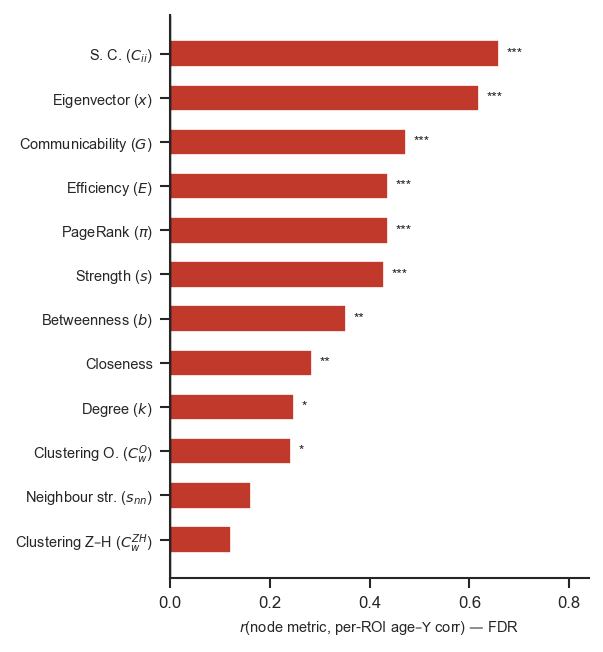

In [77]:
# disparidad y sus términos algebraicos: tautológicos como predictores de la
# pendiente-con-edad de la propia disparidad
DISP_FAMILY = ["ratio", "kY", "disparity_Y", "T2", "T3"]
KEYS_Y = [k for k in METRIC_KEYS if k not in DISP_FAMILY]

both = np.isfinite(roi_r)
rows_y = []
for key in KEYS_Y:
    m = METRIC_KEYS.index(key)
    x = roi_metric_dev[:, m]; mask = both & np.isfinite(x)
    r, p = pearson_p(x[mask], roi_r[mask])
    rows_y.append([METRIC_LABELS[key], r, p])
q = fdr_bh([t[2] for t in rows_y])
for i, t in enumerate(rows_y): t += [q[i], sig_stars(q[i])]
rows_y.sort(key=lambda t: t[1])

y = np.arange(len(rows_y))
colors = ['#c0392b' if t[1] >= 0 else '#2980b9' for t in rows_y]
fig, ax = plt.subplots(figsize=(3.6, 0.34*len(rows_y) + 0.8))
ax.barh(y, [t[1] for t in rows_y], 0.6, color=colors, zorder=2)
ax.axvline(0, color="black", lw=0.7)
for i, t in enumerate(rows_y):
    xx = t[1]; off = 0.015 if xx >= 0 else -0.015
    ax.text(xx+off, i, t[4], va="center", ha="left" if xx >= 0 else "right", fontsize=6.5)
ax.set_yticks(y); ax.set_yticklabels([t[0] for t in rows_y], fontsize=7)
ax.set_xlabel(r"$r$(node metric, per-ROI age–$\Upsilon$ corr) — FDR", fontsize=7)
xm = max(abs(min(t[1] for t in rows_y)), abs(max(t[1] for t in rows_y))) + 0.18
ax.set_xlim(0, xm); sns.despine(ax=ax)
save_fig(fig, "figSI_Y_horserace_full"); plt.show()

saved figures\figSI_MC_horserace_full.[pdf|png]


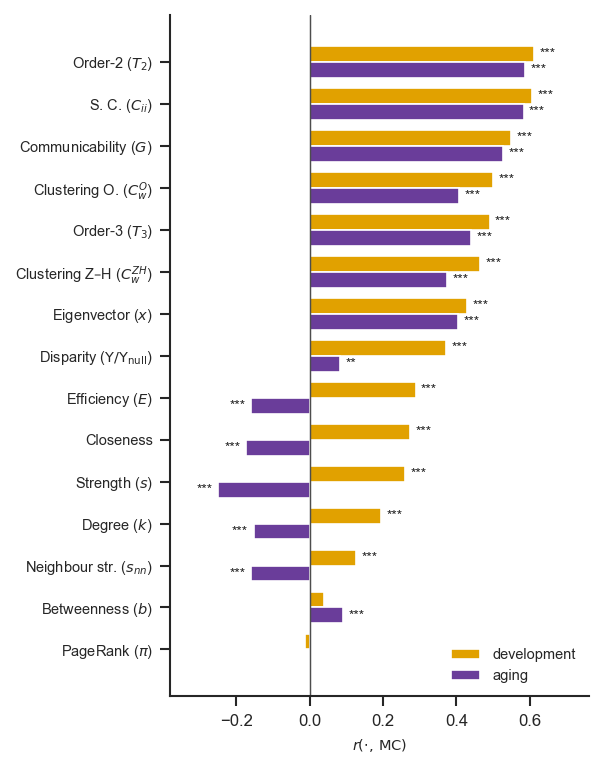

In [80]:
KEYS_MC = [k for k in METRIC_KEYS if k not in ("kY", "disparity_Y")]  # R (ratio) se queda

mc_vec = df["MC"].to_numpy()          # MC_Glob
dev = (df["age"].to_numpy() < AGE_SPLIT); ag = ~dev

rows_mc = []
for key in KEYS_MC:
    m = METRIC_KEYS.index(key)
    # Extract p-values instead of discarding them
    rd, pd = pearson_p(M_subj[dev, m], mc_vec[dev])
    ra, pa = pearson_p(M_subj[ag,  m], mc_vec[ag])
    rows_mc.append([METRIC_LABELS[key], rd, ra, pd, pa])

# FDR correction for both development and aging
qd = fdr_bh([t[3] for t in rows_mc])
qa = fdr_bh([t[4] for t in rows_mc])

# Append FDR values and significance stars
for i, t in enumerate(rows_mc):
    t.extend([qd[i], qa[i], sig_stars(qd[i]), sig_stars(qa[i])])
    
rows_mc.sort(key=lambda t: abs(t[1]) if np.isfinite(t[1]) else 0)

y = np.arange(len(rows_mc))
h = 0.38
fig, ax = plt.subplots(figsize=(3.6, 0.34*len(rows_mc) + 0.8))

ax.barh(y + h/2, [t[1] for t in rows_mc], h, color=COL["dev"],   label="development")
ax.barh(y - h/2, [t[2] for t in rows_mc], h, color=COL["aging"], label="aging")

ax.axvline(0, color="0.3", lw=0.7)

# Add stars for significance
for i, t in enumerate(rows_mc):
    # Development stars (index 7)
    xd = t[1]
    off_d = 0.015 if xd >= 0 else -0.015
    ax.text(xd + off_d, i + h/2, t[7], va="center", ha="left" if xd >= 0 else "right", fontsize=6.5)
    
    # Aging stars (index 8)
    xa = t[2]
    off_a = 0.015 if xa >= 0 else -0.015
    ax.text(xa + off_a, i - h/2, t[8], va="center", ha="left" if xa >= 0 else "right", fontsize=6.5)

ax.set_yticks(y)
ax.set_yticklabels([t[0] for t in rows_mc], fontsize=7)
ax.set_xlabel(r"$r(\cdot,\,\mathrm{MC})$")
ax.legend(frameon=False, fontsize=7, loc="lower right")

# Ensure symmetrical limits so stars don't get clipped
xm = max(abs(min(min(t[1], t[2]) for t in rows_mc)), abs(max(max(t[1], t[2]) for t in rows_mc))) + 0.15
ax.set_xlim(-xm*0.5, xm) 

sns.despine(ax=ax)
save_fig(fig, "figSI_MC_horserace_full")
plt.show()

In [43]:
from scipy.stats import pearsonr
def partial_r(x, y, z):
    rxy, rxz, ryz = pearsonr(x,y)[0], pearsonr(x,z)[0], pearsonr(y,z)[0]
    return (rxy - rxz*ryz) / np.sqrt((1-rxz**2)*(1-ryz**2))

ag = df[df["cohort"] == "aging"].copy()
dens = []
for A in ag["connectome"]:
    A = _mat(A); n = A.shape[0]
    dens.append((A > 0).sum() / (n*(n-1)))      # edge density
ag["density"] = dens

for col, lab in [("comm_mean", "C_ii"), ("MC", "MC")]:
    r  = pearsonr(ag[col], ag["age"])[0]
    rp = partial_r(ag[col].values, ag["age"].values, ag["density"].values)
    print(f"{lab}:  r(age)={r:+.3f}   partial r(age|density)={rp:+.3f}")

C_ii:  r(age)=+0.420   partial r(age|density)=+0.486
MC:  r(age)=+0.295   partial r(age|density)=+0.270


saved figures\figSI_order2_factorisation.[pdf|png]


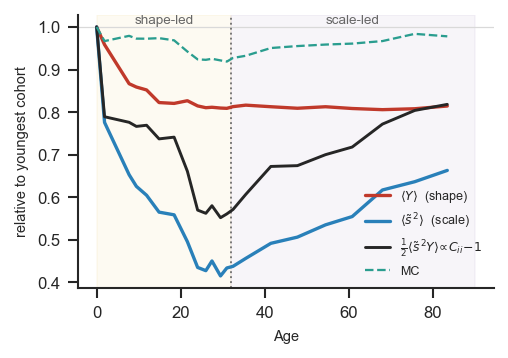

In [86]:
# === SI Fig 11 · factorisation of the order-2 term across the lifespan =======
# C_ii - 1 ≈ T2 = ½⟨s̃²_i Y_i⟩ splits into a SCALE factor ⟨s̃²⟩ and a SHAPE
# factor ⟨Y⟩ (disparity), both on the spectrally-normalised W̃ (ρ=0.99).
def _age_traj(age, y, nq=24):
    age = np.asarray(age, float); y = np.asarray(y, float)
    m = np.isfinite(age) & np.isfinite(y); age, y = age[m], y[m]
    q = np.quantile(age, np.linspace(0, 1, nq + 1))
    b = np.clip(np.digitize(age, q[1:-1]), 0, nq - 1)
    ks = [k for k in range(nq) if (b == k).any()]
    return (np.array([age[b == k].mean() for k in ks]),
            np.array([y[b == k].mean()  for k in ks]))

D = df.dropna(subset=["age", "s2n_mean", "Y_mean", "T2_mean", "MC"]).copy()
series = [
    ("Ratio",   r"$\langle Y\rangle$  (shape)",                      COL["disp"], 1.6, "-"),
    ("s2n_mean", r"$\langle \tilde s^{\,2}\rangle$  (scale)",          COL["comm"], 1.6, "-"),
    ("T2_mean",  r"$\frac{1}{2}\langle \tilde s^{\,2}Y\rangle\!\propto\! C_{ii}\!-\!1$", "0.15", 1.4, "-"),
    ("MC",       r"MC",                                               COL["mc"],   1.1, "--"),
]
fig, ax = plt.subplots(figsize=(3.4, 2.4))
for col, lab, c, lw, ls in series:
    cx, cy = _age_traj(D["age"].values, D[col].values)
    ax.plot(cx, cy / cy[0], color=c, lw=lw, ls=ls, label=lab, zorder=4)
ax.axvline(AGE_SPLIT, color="0.45", ls=":", lw=0.9, zorder=2)
ax.axhline(1.0, color="0.85", lw=0.6, zorder=1)
ymax = ax.get_ylim()[1]
ax.axvspan(D["age"].min(), AGE_SPLIT, color=COL["dev"],   alpha=0.05, zorder=0)
ax.axvspan(AGE_SPLIT, D["age"].max(), color=COL["aging"], alpha=0.05, zorder=0)
ax.text(AGE_SPLIT*0.5, ymax, "shape-led", ha="center", va="top", fontsize=6.5, color="0.4")
ax.text((AGE_SPLIT+D["age"].max())/2, ymax, "scale-led", ha="center", va="top", fontsize=6.5, color="0.4")
ax.set_xlabel("Age"); ax.set_ylabel("relative to youngest cohort")
ax.legend(frameon=False, fontsize=6, loc="lower right")
sns.despine(ax=ax); fig.tight_layout()
save_fig(fig, "figSI_order2_factorisation"); plt.show()